# DISCO Treatment Effect Demo - Synthetic Scenario

This notebook evaluates DISCO and simple baselines on the synthetic scenario generated via the CLI.

Run the scenario commands (synth, train-devices --dataset scenario, probe --dataset scenario) before executing the cells below.

In [20]:
import os

SEED = 42

number_of_devices = 10 # total devices in the scenario
number_of_deployed_devices = 10 # out of which we train models

number_of_probe_samples = 800
number_of_probe_to_use = 240

number_of_features = 10
number_of_training_samples_per_device = 5000
number_of_queries = 80

target_device_index = 0
target_effect_scale = 0.3

pregrid_thetas = [0.0, 0.25, 0.5, 0.75, 1.0]
postgrid_thetas = [1.2, 1.35, 1.5, 1.65, 1.8, 2.0]

num_anchors_for_matching = 12
anchor_kernel_bandwidth = 0.20
ridge_regularization_lambda = 0.01

counterfactual_mode = 's'  # 's' (secure) and 'p' (proxy) for the DISCO run
base_offset_std = 0.40 # stddev for device base offsets (heterogeneity)
peer_effect_std = 0.30 # stddev of peer treatment strengths around the target’s
generator_noise_std = 0.03 # observation noise injected by the generator

intervention_config_yaml = "experiments/configs/tabular_interventions.yaml"

scenario_output_dir = "experiments/results/synth_run"
scenario_path = os.path.join(scenario_output_dir, "scenario.npz")
device_output_dir = "experiments/synth_devices"
probes_output_dir = os.path.join(scenario_output_dir, "probes")
explain_output_dir = os.path.join(scenario_output_dir, "explain")


print(f"""
# 1 Generate a scenario (with heterogeneity + noise):
    python -m disco.cli.main synth --p {number_of_features} --N {number_of_devices} --m {number_of_probe_samples} --alpha {target_effect_scale} --theta0 "{pregrid_thetas}" --theta "{postgrid_thetas}" --K {num_anchors_for_matching} --tau {anchor_kernel_bandwidth} --lam {ridge_regularization_lambda} --mode {counterfactual_mode} --base-jitter {base_offset_std} --peer-alpha-std {peer_effect_std} --noise-std {generator_noise_std} --out {scenario_output_dir} --seed {SEED}

# 2 Train heterogeneous models on scenario data:
    python -m disco.cli.main train-devices --dataset scenario --scenario {scenario_path} --samples {number_of_training_samples_per_device} --N {number_of_deployed_devices} --out {device_output_dir} --seed {SEED}
      
# 3 Produce probe trajectories matching those models:
    python -m disco.cli.main probe --devices {device_output_dir} --dataset scenario --scenario {scenario_path} --probes {number_of_probe_to_use} --theta0 "{pregrid_thetas}" --interventions {intervention_config_yaml} --out {probes_output_dir} --seed {SEED}
      
# 4 (Optional) Run the CLI explanations:
    python -m disco.cli.main explain --devices {device_output_dir} --probes {probes_output_dir} --dataset scenario --scenario {scenario_path} --targets {target_device_index} --queries {number_of_queries} --interventions {intervention_config_yaml} --K {num_anchors_for_matching} --tau {anchor_kernel_bandwidth} --lam {ridge_regularization_lambda} --mode {counterfactual_mode} --out {explain_output_dir} --seed {SEED}
""")


# 1 Generate a scenario (with heterogeneity + noise):
    python -m disco.cli.main synth --p 10 --N 10 --m 800 --alpha 0.3 --theta0 "[0.0, 0.25, 0.5, 0.75, 1.0]" --theta "[1.2, 1.35, 1.5, 1.65, 1.8, 2.0]" --K 12 --tau 0.2 --lam 0.01 --mode s --base-jitter 0.4 --peer-alpha-std 0.3 --noise-std 0.03 --out experiments/results/synth_run --seed 42

# 2 Train heterogeneous models on scenario data:
    python -m disco.cli.main train-devices --dataset scenario --scenario experiments/results/synth_run\scenario.npz --samples 5000 --N 10 --out experiments/synth_devices --seed 42
      
# 3 Produce probe trajectories matching those models:
    python -m disco.cli.main probe --devices experiments/synth_devices --dataset scenario --scenario experiments/results/synth_run\scenario.npz --probes 240 --theta0 "[0.0, 0.25, 0.5, 0.75, 1.0]" --interventions experiments/configs/tabular_interventions.yaml --out experiments/results/synth_run\probes --seed 42
      
# 4 (Optional) Run the CLI explanations:
    

In [2]:
# Add parent directory to path
import sys
import os
sys.path.append(os.path.abspath('../..'))


In [3]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from disco.synth.generator import SyntheticScenario
from disco.explain.disco_algorithm import DiscoRunner
from disco.explain.baselines import BaselineRunner
from disco.interventions.tabular import FeatureAdd, FeatureScale, ClampedShift
from disco.interventions.grids import Grids
from disco.counterfactual.pmode import PModeCounterfactual
from disco.cli.main import compute_probe_trajectories, load_devices
from disco.data.loaders import stack_prewindow


def load_scenario_bundle(scenario_dir: Path):
    scenario_dir = Path(scenario_dir)
    scenario = SyntheticScenario.load(scenario_dir / 'scenario.npz')
    trajectories = {}
    sample_rows = None
    probes_dir = scenario_dir / 'probes'
    if probes_dir.exists():
        for npy_path in probes_dir.glob('*.npy'):
            if npy_path.name == 'X_probe.npy':
                continue
            parts = npy_path.stem.split('_', 2)
            if len(parts) < 3:
                continue
            device_id = '{}_{}'.format(parts[0], parts[1])
            interv_name = '_'.join(parts[2:])
            data = np.load(npy_path)
            trajectories[(device_id, interv_name)] = data
            if sample_rows is None:
                sample_rows = data.shape[0]
    X_probe = scenario.X_probe
    if sample_rows is not None and sample_rows < len(X_probe):
        X_probe = X_probe[:sample_rows]
    return scenario, trajectories, X_probe


runner = DiscoRunner()
baseline_runner = BaselineRunner()
pmode_builder = PModeCounterfactual()


In [4]:
SCENARIO_DIR = Path('..').resolve() / 'results' / 'synth_run'
MODEL_DIR = Path('..').resolve() / 'synth_devices'

scenario, scenario_trajs, scenario_X_probe = load_scenario_bundle(SCENARIO_DIR)
model_devices = load_devices(str(MODEL_DIR))

print('Oracle devices: {}'.format(len(scenario.devices)))
print('Model devices: {}'.format(len(model_devices)))
print('Probe rows: {}'.format(scenario_X_probe.shape[0]))
print('Theta0: {}'.format(scenario.theta0))
print('Theta: {}'.format(scenario.theta))


Oracle devices: 30
Model devices: 30
Probe rows: 1200
Theta0: [0.   0.25 0.5  0.75 1.  ]
Theta: [1.2 1.3 1.4 1.5 1.6 1.7 1.8 2.  2.2]


In [5]:
INTERVENTIONS = {
    'intensity_shift': FeatureAdd(feat_idx=0, delta_max=float(scenario.theta.max()), name='intensity_shift'),
    'add_f1': FeatureAdd(feat_idx=1, delta_max=1.5, name='add_f1'),
    'scale_f2': FeatureScale(feat_idx=2, scale_max=0.5, name='scale_f2'),
    'clamped_f4': ClampedShift(feat_idx=4, shift_max=2.0, lower=-2.0, upper=2.0, name='clamped_f4'),
}

intervention_key = 'add_f1'
intervention = INTERVENTIONS[intervention_key]
print('Selected intervention: {}'.format(intervention.name))


Selected intervention: add_f1


In [6]:
grids = Grids(theta0=scenario.theta0, theta=scenario.theta)
target_class = 0

trajectories_model = compute_probe_trajectories(
    devices=model_devices,
    X_probe=scenario_X_probe,
    interventions=[intervention],
    theta0=scenario.theta0,
    dp_noise_std=0.0,
    seed=0,
    target_class=target_class,
)

trajectories_oracle = compute_probe_trajectories(
    devices=scenario.devices,
    X_probe=scenario_X_probe,
    interventions=[intervention],
    theta0=scenario.theta0,
    dp_noise_std=0.0,
    seed=0,
    target_class=target_class,
)

x_star = scenario.x_star
target_idx = 0

output = runner.run(
    devices=model_devices,
    target_idx=target_idx,
    x_star=x_star,
    X_probe=scenario_X_probe,
    trajectories=trajectories_model,
    grids=grids,
    intervention=intervention,
    target_class=target_class,
    mode='s',
    lam=0.01,
)
te_output = output.te_output
result = {'te_output': te_output, 'weights': output.weights}
result.update(output.diagnostics)
print('Weight L1 sum: {:.3f}'.format(np.sum(output.weights)))
print('AUC(|tau|): {:.4f}'.format(np.trapz(np.abs(te_output.tau), te_output.theta)))


Weight L1 sum: 1.000
AUC(|tau|): 0.0745


In [7]:
theta_post = te_output.theta
weights_disco = output.weights

oracle_output = baseline_runner.baseline_oracle_ground_truth(
    devices=model_devices,
    trajectories=trajectories_model,
    theta0=scenario.theta0,
    x_star=x_star,
    grids=grids,
    intervention=intervention,
    target_idx=target_idx,
    target_class=target_class,
    oracle_devices=scenario.devices,
    oracle_trajectories=trajectories_oracle,
    oracle_theta0=scenario.theta0,
)
tau_true_oracle = oracle_output.tau
w_star = np.array(oracle_output.meta["weights"])

w_avg = np.ones_like(weights_disco) / len(weights_disco)
y_syn_avg, _ = pmode_builder.build(
    w=w_avg,
    devices=model_devices,
    X_probe=scenario_X_probe,
    anchor_sel=result['anchor_selection'],
    x_star=x_star,
    grids=grids,
    intervention=intervention,
    target_device=model_devices[target_idx],
    target_class=target_class,
)
tau_est_avg = te_output.y_t - y_syn_avg

anchor_sel = result['anchor_selection']
y_t_pre, X_peers_pre = stack_prewindow(
    trajectories=trajectories_model,
    target=model_devices[target_idx],
    devices=model_devices,
    anchor_sel=anchor_sel,
    intervention=intervention,
    theta0=scenario.theta0,
)
errs = np.linalg.norm(X_peers_pre - y_t_pre[:, None], axis=0)
best_idx = int(np.argmin(errs))
w_best = np.zeros_like(weights_disco)
w_best[best_idx] = 1.0
y_syn_best, _ = pmode_builder.build(
    w=w_best,
    devices=model_devices,
    X_probe=scenario_X_probe,
    anchor_sel=anchor_sel,
    x_star=x_star,
    grids=grids,
    intervention=intervention,
    target_device=model_devices[target_idx],
    target_class=target_class,
)
tau_est_best = te_output.y_t - y_syn_best

topk_output = baseline_runner.baseline_topk_avg(
    devices=model_devices,
    trajectories=trajectories_model,
    anchor_sel=anchor_sel,
    theta0=scenario.theta0,
    x_star=x_star,
    grids=grids,
    intervention=intervention,
    target_idx=target_idx,
    Kp=5,
    target_class=target_class,
)
tau_est_topk = topk_output.tau

def max_abs_error(a, b):
    return float(np.max(np.abs(a - b)))

print('oracle w* L1 = {:.2f}'.format(np.sum(w_star)))
print('max |tau_true_oracle - DISCO| = {:.2e}'.format(max_abs_error(tau_true_oracle, te_output.tau)))
print('max |tau_true_oracle - best peer| = {:.2e}'.format(max_abs_error(tau_true_oracle, tau_est_best)))
print('max |tau_true_oracle - avg| = {:.2e}'.format(max_abs_error(tau_true_oracle, tau_est_avg)))
print('max |tau_true_oracle - topK| = {:.2e}'.format(max_abs_error(tau_true_oracle, tau_est_topk)))


oracle w* L1 = 1.00
max |tau_true_oracle - DISCO| = 1.21e-01
max |tau_true_oracle - best peer| = 3.36e-01
max |tau_true_oracle - avg| = 1.78e-01
max |tau_true_oracle - topK| = 2.52e-01


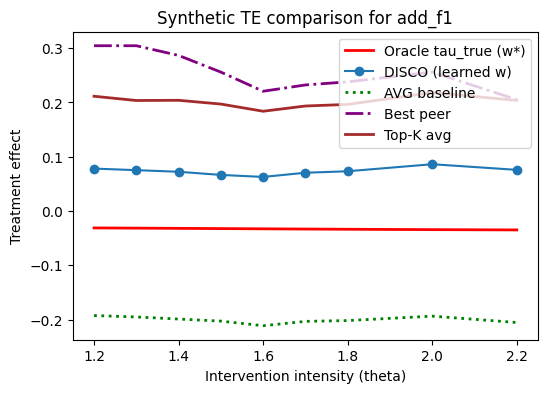

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(theta_post, tau_true_oracle, color='red', linewidth=2, label='Oracle tau_true (w*)')
ax.plot(theta_post, te_output.tau, marker='o', color='C0', label='DISCO (learned w)')
ax.plot(theta_post, tau_est_avg, color='green', linestyle=':', linewidth=2, label='AVG baseline')
ax.plot(theta_post, tau_est_best, color='purple', linestyle='-.', linewidth=2, label='Best peer')
ax.plot(theta_post, tau_est_topk, color='brown', linewidth=2, label='Top-K avg')
ax.set_xlabel('Intervention intensity (theta)')
ax.set_ylabel('Treatment effect')
ax.set_title('Synthetic TE comparison for {}'.format(intervention.name))
ax.legend()
plt.show()
